# 📊 Week 7 - Task 12: Unsupervised Learning & Dimensionality Reduction
## Market Basket Analysis Project

**AI/ML Fellowship - GDGOC 2026**

---

### 📋 Topics Covered:

| # | Topic | Description |
|---|-------|-------------|
| 1 | **K-Means Clustering** | Implementation from Scratch + sklearn comparison |
| 2 | **Hierarchical Clustering** | Dendrograms & Agglomerative Clustering |
| 3 | **PCA** | Principal Component Analysis for Dimensionality Reduction |
| 4 | **t-SNE** | t-Distributed Stochastic Neighbor Embedding Visualization |
| 5 | **Association Rule Mining** | Apriori Algorithm — Market Basket Analysis Project |

---

## 🔧 Setup & Library Imports

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.datasets import make_blobs, load_iris, load_wine, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Association Rule Mining
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Visualization
import plotly.express as px

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
# Part 1: K-Means Clustering (from Scratch) 🎯

## 1.1 Understanding K-Means Algorithm

**K-Means** is one of the most popular unsupervised learning algorithms for partitioning data into K groups.

### Algorithm Steps:
1. **Initialize** K centroids randomly (we use K-Means++ for better initialization)
2. **Assign** each data point to the nearest centroid
3. **Update** each centroid to the mean of its assigned points
4. **Repeat** steps 2-3 until convergence

### Key Concepts:
- **Inertia (WCSS)**: Within-Cluster Sum of Squares — measures cluster compactness
- **Elbow Method**: Finds the optimal K by looking for the "elbow" in the inertia curve
- **Silhouette Score**: Measures how similar a point is to its own cluster vs other clusters (-1 to 1)

## 1.2 K-Means Implementation from Scratch

In [2]:
class KMeansFromScratch:
    """K-Means Clustering implemented from scratch with K-Means++ initialization."""

    def __init__(self, n_clusters=3, max_iters=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iters_ = 0
        self.history = {'centroids': [], 'labels': [], 'inertia': []}

    def _init_centroids(self, X):
        """K-Means++ initialization for better convergence."""
        np.random.seed(self.random_state)
        centroids = [X[np.random.randint(X.shape[0])]]
        for _ in range(1, self.n_clusters):
            dists = np.min([np.sum((X - c)**2, axis=1) for c in centroids], axis=0)
            probs = dists / dists.sum()
            centroids.append(X[np.random.choice(X.shape[0], p=probs)])
        return np.array(centroids)

    def _assign_clusters(self, X):
        dists = np.array([np.sqrt(np.sum((X - c)**2, axis=1)) for c in self.centroids])
        return np.argmin(dists, axis=0)

    def _update_centroids(self, X, labels):
        new_centroids = np.zeros_like(self.centroids)
        for k in range(self.n_clusters):
            pts = X[labels == k]
            new_centroids[k] = pts.mean(axis=0) if len(pts) > 0 else self.centroids[k]
        return new_centroids

    def _compute_inertia(self, X, labels):
        return sum(np.sum((X[labels == k] - self.centroids[k])**2) for k in range(self.n_clusters))

    def fit(self, X):
        self.centroids = self._init_centroids(X)
        for i in range(self.max_iters):
            self.labels_ = self._assign_clusters(X)
            new_centroids = self._update_centroids(X, self.labels_)
            self.history['centroids'].append(self.centroids.copy())
            self.history['labels'].append(self.labels_.copy())
            self.inertia_ = self._compute_inertia(X, self.labels_)
            self.history['inertia'].append(self.inertia_)
            if np.sum((new_centroids - self.centroids)**2) < self.tol:
                self.n_iters_ = i + 1
                break
            self.centroids = new_centroids
        else:
            self.n_iters_ = self.max_iters
        self.labels_ = self._assign_clusters(X)
        self.inertia_ = self._compute_inertia(X, self.labels_)
        return self

    def predict(self, X):
        return self._assign_clusters(X)

print("✅ KMeansFromScratch class defined!")

✅ KMeansFromScratch class defined!


## 1.3 Testing on Synthetic Data

In [3]:
# Generate synthetic data with 4 clear clusters
X_blobs, y_blobs = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)

# Fit our K-Means
kmeans_scratch = KMeansFromScratch(n_clusters=4, random_state=42)
kmeans_scratch.fit(X_blobs)

print(f"Converged in {kmeans_scratch.n_iters_} iterations")
print(f"Inertia (WCSS): {kmeans_scratch.inertia_:.2f}")

Converged in 2 iterations
Inertia (WCSS): 607.29


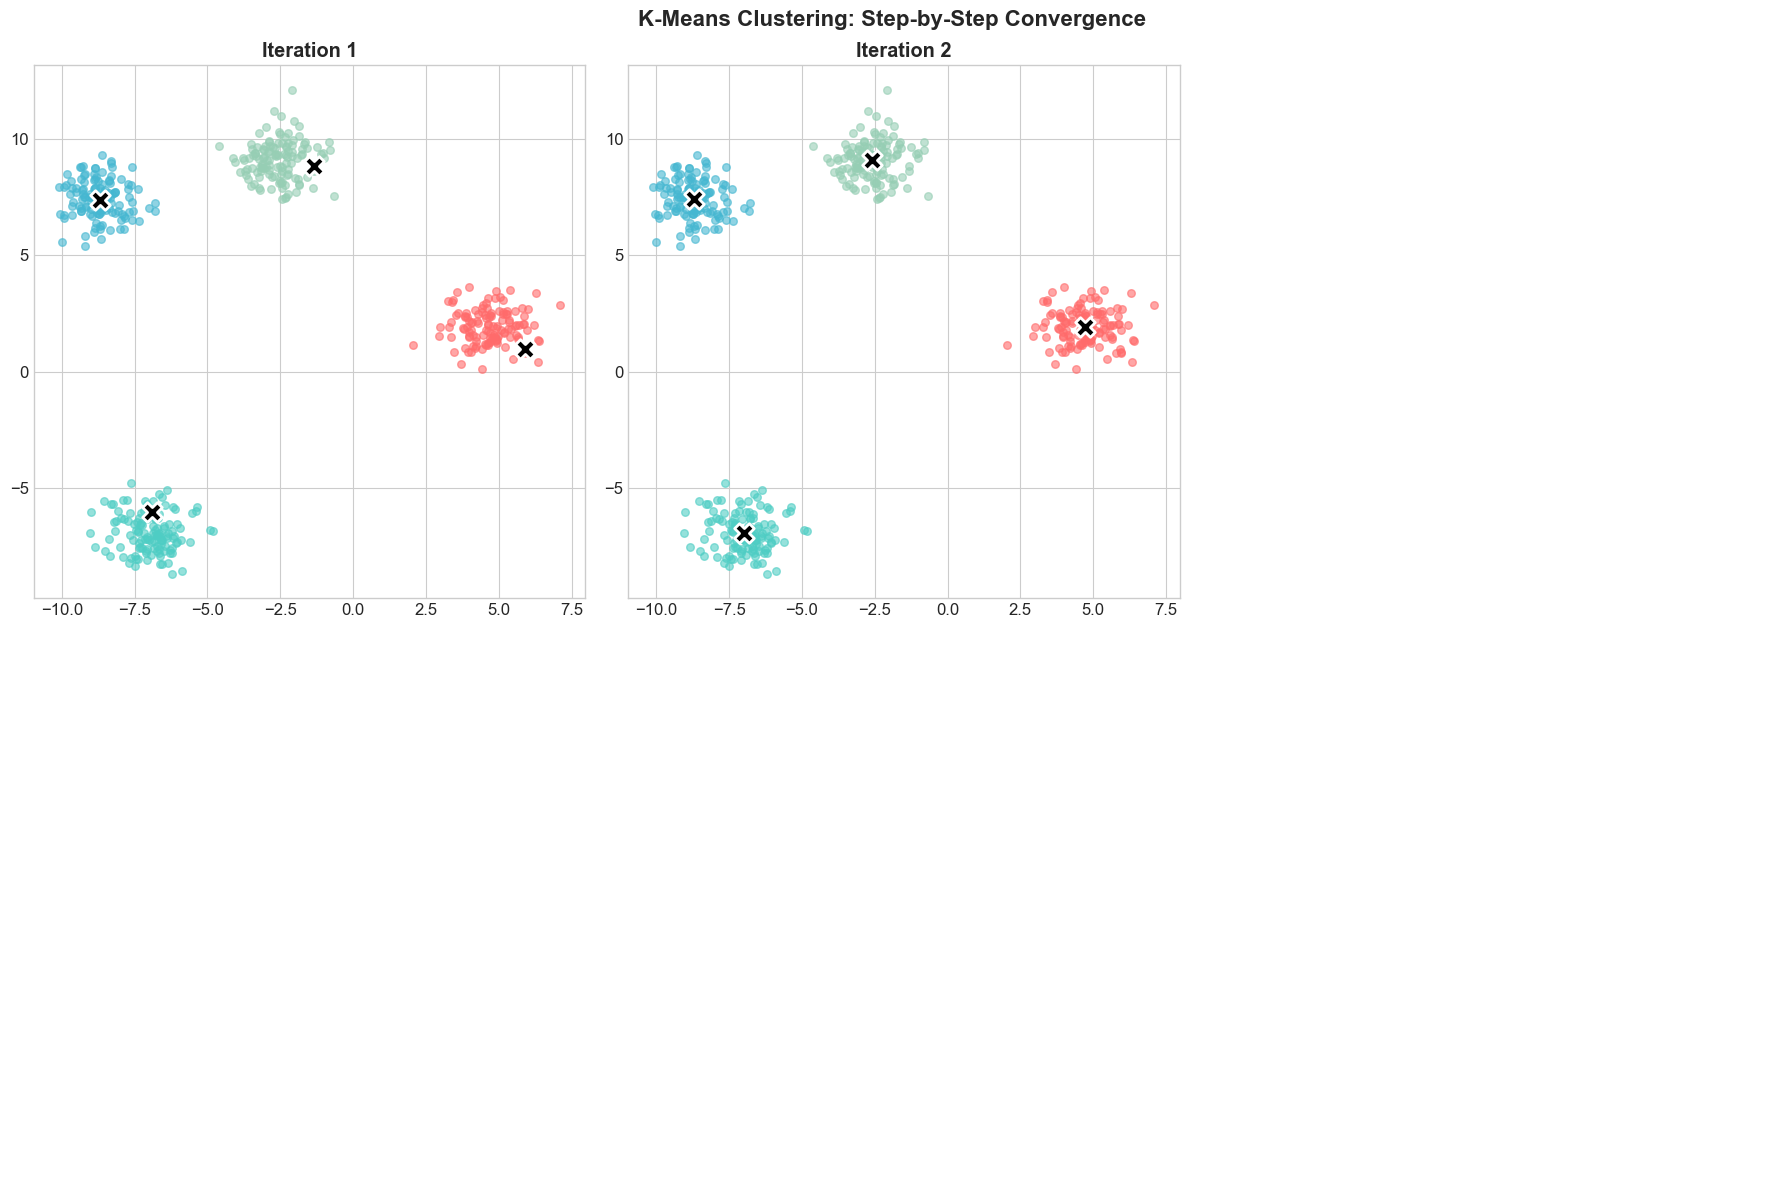

In [4]:
# Visualize convergence steps
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('K-Means Clustering: Step-by-Step Convergence', fontsize=16, fontweight='bold')
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
n_hist = len(kmeans_scratch.history['centroids'])
# Only use valid indices that exist in the history
steps = list(range(min(6, n_hist)))

for idx, ax in enumerate(axes.flat):
    if idx < len(steps):
        s = steps[idx]
        lbl = kmeans_scratch.history['labels'][s]
        cen = kmeans_scratch.history['centroids'][s]
        for k in range(4):
            ax.scatter(X_blobs[lbl==k, 0], X_blobs[lbl==k, 1], c=colors[k], alpha=0.6, s=30)
        ax.scatter(cen[:, 0], cen[:, 1], c='black', marker='X', s=200, edgecolors='white', linewidth=2, zorder=5)
        ax.set_title(f'Iteration {s+1}', fontweight='bold')
    else:
        ax.axis('off')
plt.tight_layout()
plt.show()

## 1.4 Elbow Method for Optimal K

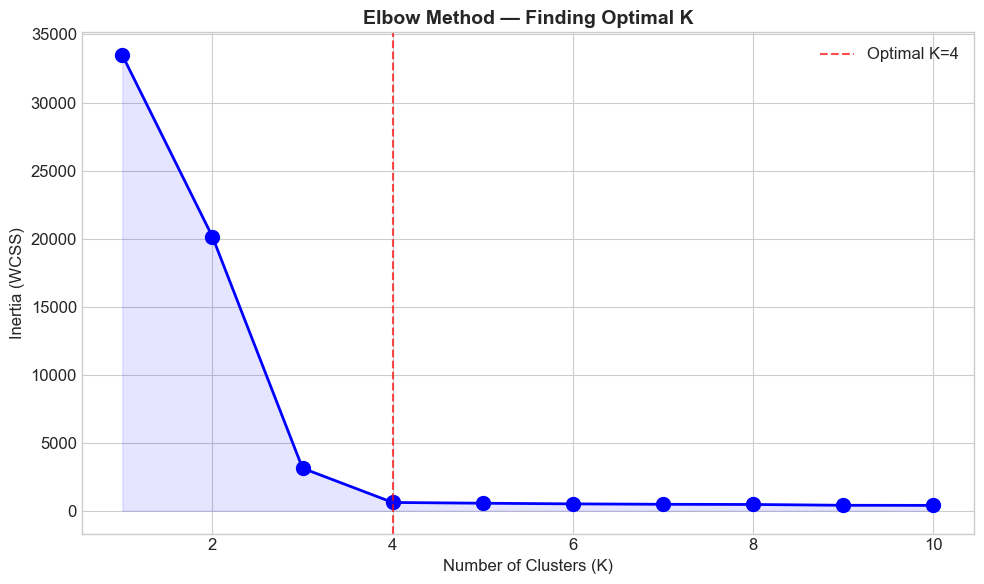

📊 The 'elbow' at K=4 indicates the optimal number of clusters


In [5]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeansFromScratch(n_clusters=k, random_state=42)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
plt.fill_between(K_range, inertias, alpha=0.1, color='blue')
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal K=4')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — Finding Optimal K', fontweight='bold', fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
print("📊 The 'elbow' at K=4 indicates the optimal number of clusters")

## 1.5 Comparison with sklearn's KMeans

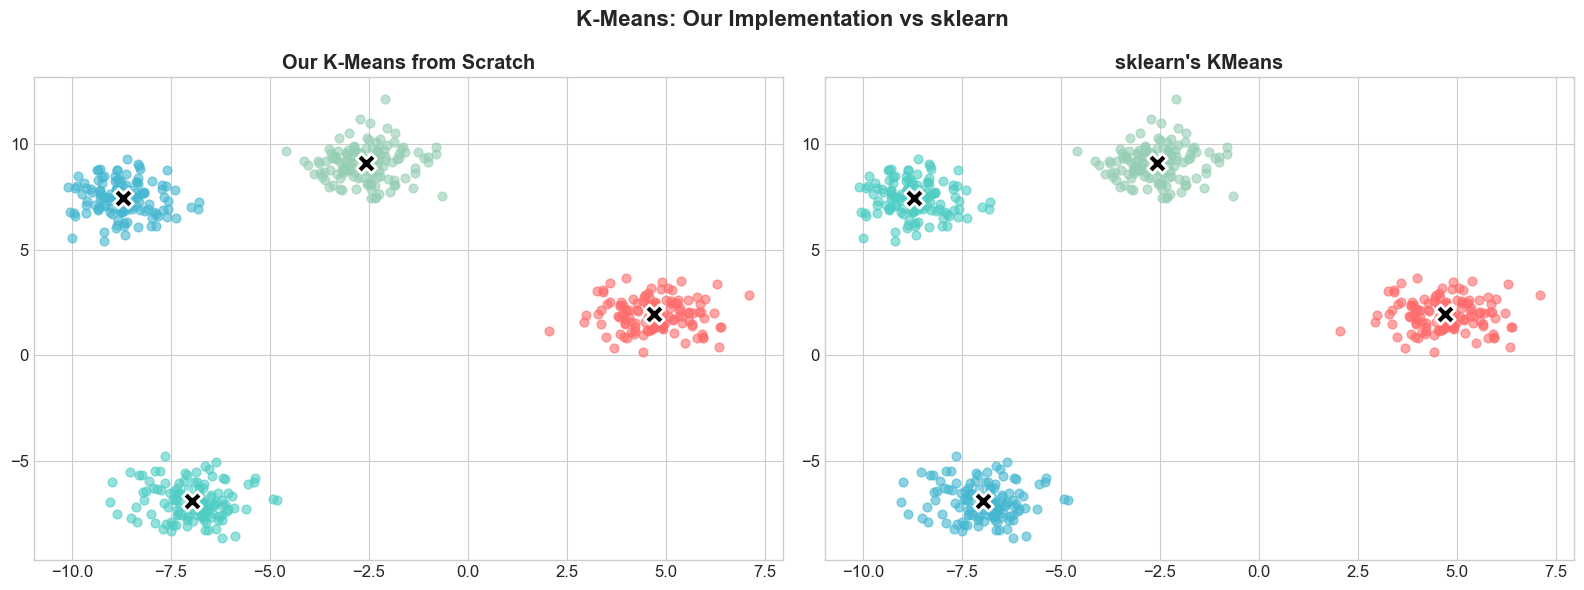


Metric                    Ours            sklearn        
-------------------------------------------------------
Inertia                   607.29          607.29         
Silhouette Score          0.8336          0.8336         


In [6]:
sklearn_km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_blobs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for k in range(4):
    axes[0].scatter(X_blobs[kmeans_scratch.labels_==k, 0], X_blobs[kmeans_scratch.labels_==k, 1], c=colors[k], alpha=0.6, s=40)
axes[0].scatter(kmeans_scratch.centroids[:,0], kmeans_scratch.centroids[:,1], c='black', marker='X', s=200, edgecolors='white', linewidth=2, zorder=5)
axes[0].set_title('Our K-Means from Scratch', fontweight='bold')

for k in range(4):
    axes[1].scatter(X_blobs[sklearn_km.labels_==k, 0], X_blobs[sklearn_km.labels_==k, 1], c=colors[k], alpha=0.6, s=40)
axes[1].scatter(sklearn_km.cluster_centers_[:,0], sklearn_km.cluster_centers_[:,1], c='black', marker='X', s=200, edgecolors='white', linewidth=2, zorder=5)
axes[1].set_title("sklearn's KMeans", fontweight='bold')
plt.suptitle('K-Means: Our Implementation vs sklearn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n{'Metric':<25} {'Ours':<15} {'sklearn':<15}")
print("-"*55)
print(f"{'Inertia':<25} {kmeans_scratch.inertia_:<15.2f} {sklearn_km.inertia_:<15.2f}")
print(f"{'Silhouette Score':<25} {silhouette_score(X_blobs, kmeans_scratch.labels_):<15.4f} {silhouette_score(X_blobs, sklearn_km.labels_):<15.4f}")

## 1.6 Silhouette Analysis

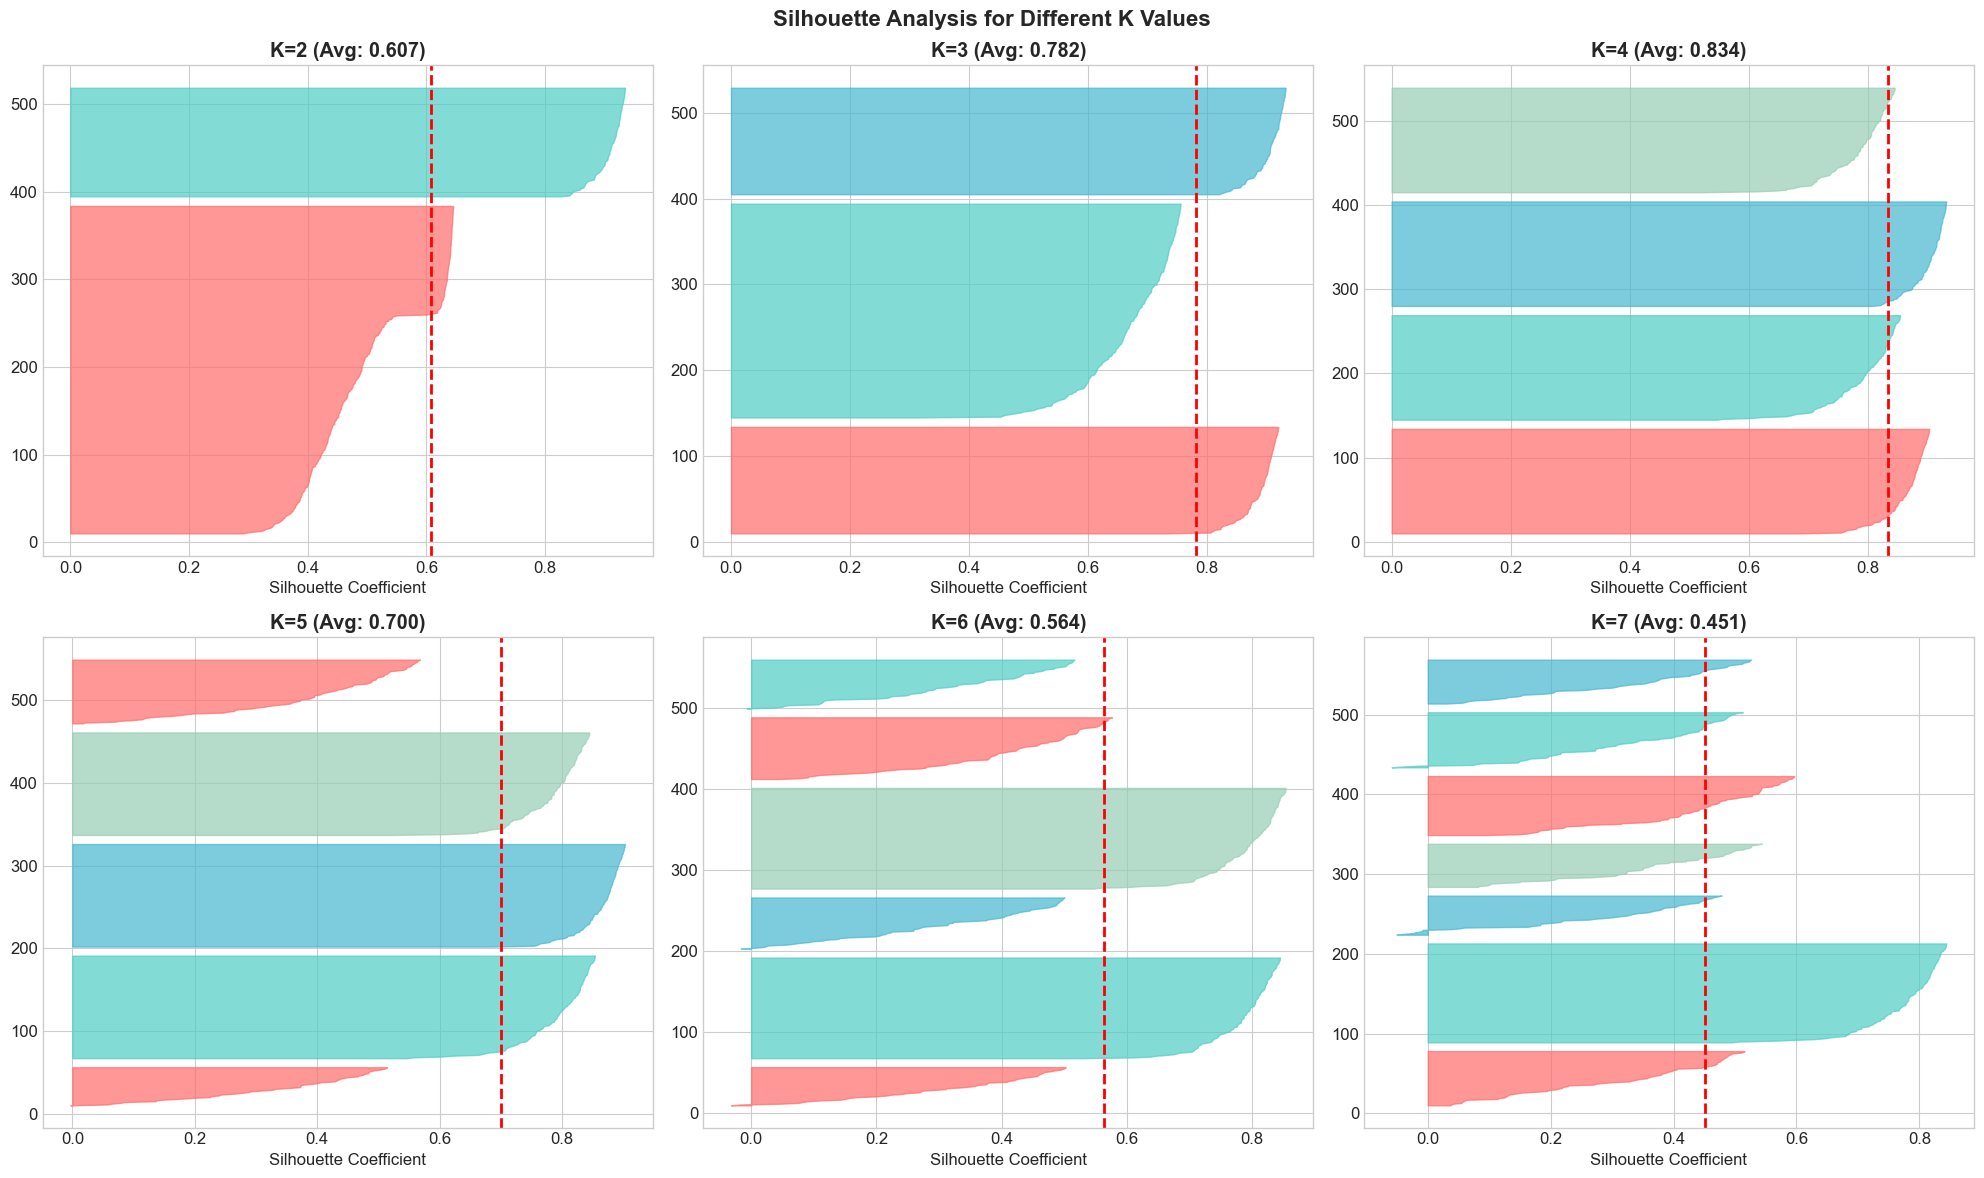

📊 K=4 achieves the best silhouette score — confirms our elbow method result!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Silhouette Analysis for Different K Values', fontsize=16, fontweight='bold')
for idx, k in enumerate(range(2, 8)):
    ax = axes.flat[idx]
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_blobs)
    avg = silhouette_score(X_blobs, labels)
    vals = silhouette_samples(X_blobs, labels)
    y_lower = 10
    for i in range(k):
        iv = np.sort(vals[labels == i])
        y_upper = y_lower + len(iv)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, iv, alpha=0.7, color=colors[i % len(colors)])
        y_lower = y_upper + 10
    ax.axvline(x=avg, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'K={k} (Avg: {avg:.3f})', fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient')
plt.tight_layout()
plt.show()
print("📊 K=4 achieves the best silhouette score — confirms our elbow method result!")

---
# Part 2: Hierarchical Clustering 🌳

## 2.1 Understanding Hierarchical Clustering

**Hierarchical Clustering** builds a tree-like hierarchy of clusters:

- **Agglomerative (Bottom-Up)**: Starts with each point as its own cluster, merges closest pairs
- **Divisive (Top-Down)**: Starts with one cluster, recursively splits

### Linkage Methods:
| Method | Description |
|--------|-------------|
| **Single** | Min distance between clusters (prone to chaining) |
| **Complete** | Max distance (produces compact clusters) |
| **Average** | Average of all pairwise distances |
| **Ward** | Minimizes total within-cluster variance (most popular) |

## 2.2 Dendrogram Visualization

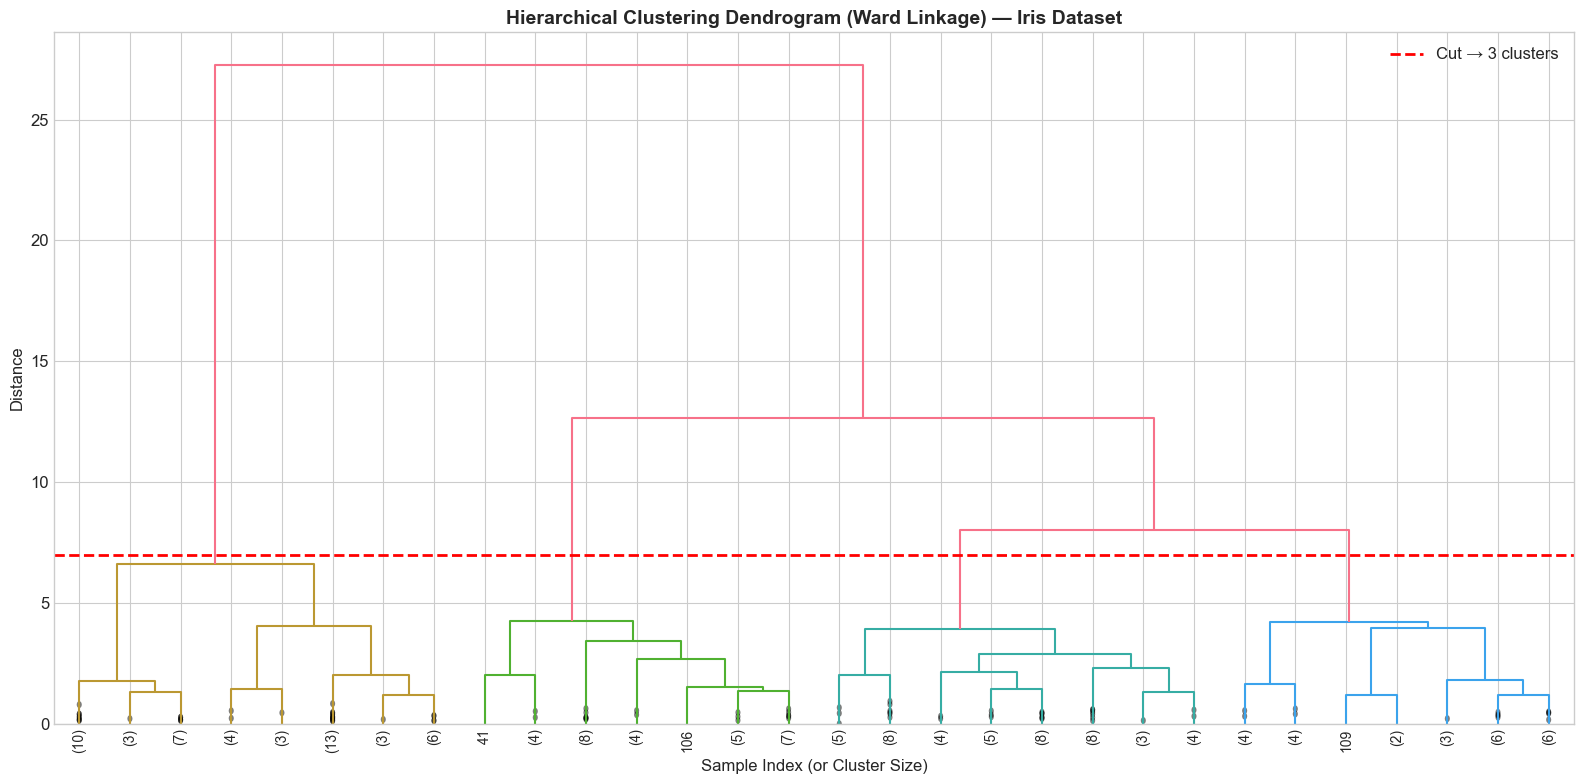

🌳 Cutting at distance ≈ 7 yields 3 clusters (matching Iris species)


In [8]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Dendrogram with Ward linkage
Z = linkage(X_iris_scaled, method='ward')

plt.figure(figsize=(16, 8))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True, color_threshold=7)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage) — Iris Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index (or Cluster Size)')
plt.ylabel('Distance')
plt.axhline(y=7, color='r', linestyle='--', linewidth=2, label='Cut → 3 clusters')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
print("🌳 Cutting at distance ≈ 7 yields 3 clusters (matching Iris species)")

## 2.3 Comparing Linkage Methods

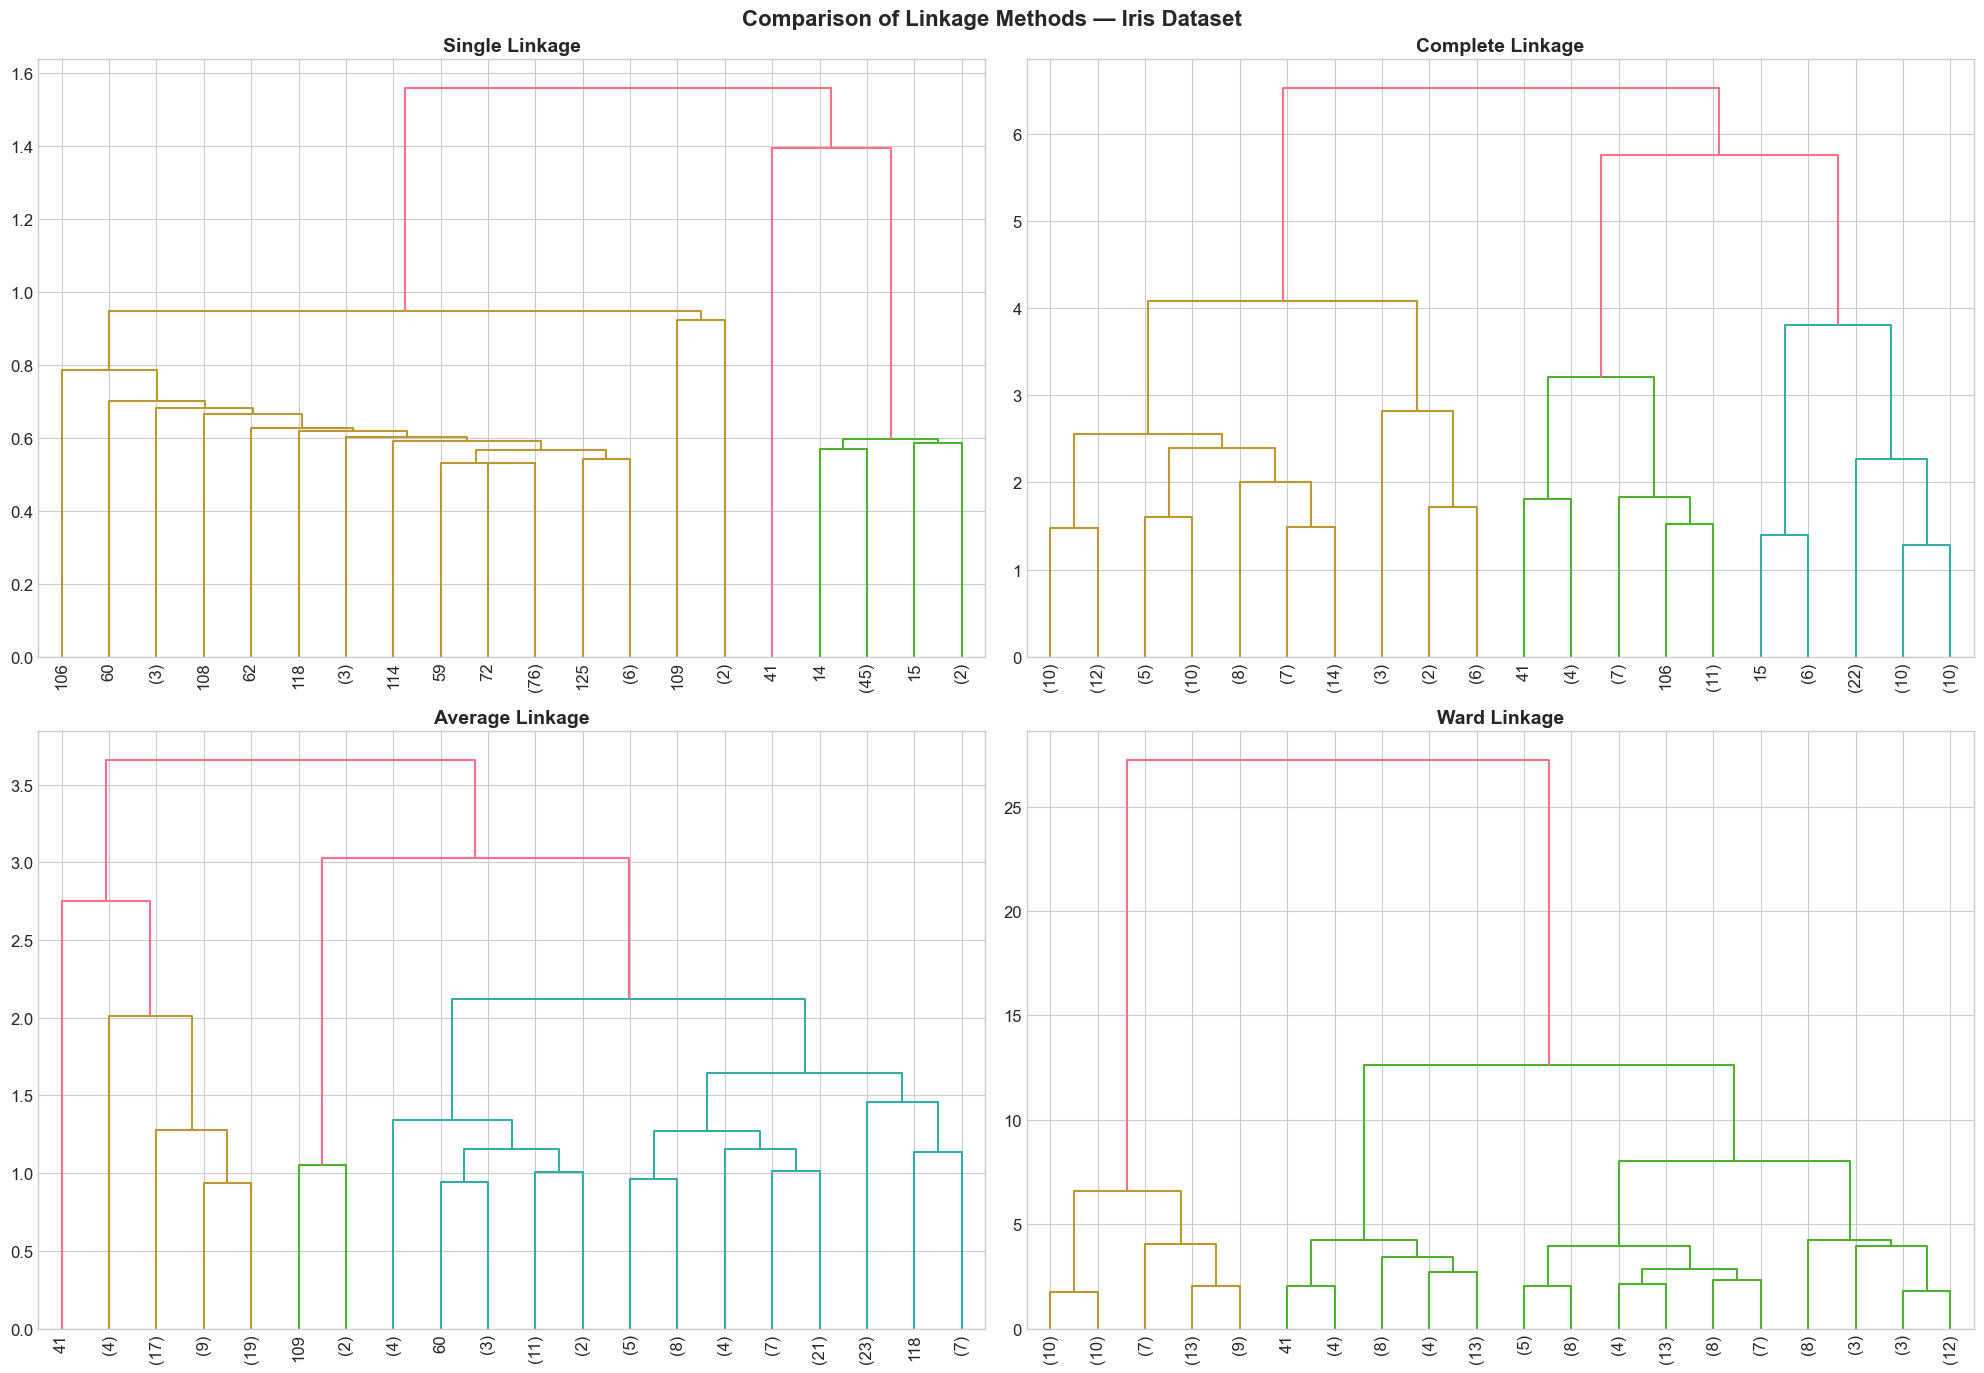

📊 Ward linkage produces the most balanced and compact clusters


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
for idx, method in enumerate(['single', 'complete', 'average', 'ward']):
    ax = axes.flat[idx]
    dendrogram(linkage(X_iris_scaled, method=method), truncate_mode='lastp', p=20, leaf_rotation=90, ax=ax)
    ax.set_title(f'{method.capitalize()} Linkage', fontsize=14, fontweight='bold')
plt.suptitle('Comparison of Linkage Methods — Iris Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("📊 Ward linkage produces the most balanced and compact clusters")

## 2.4 Agglomerative Clustering vs K-Means

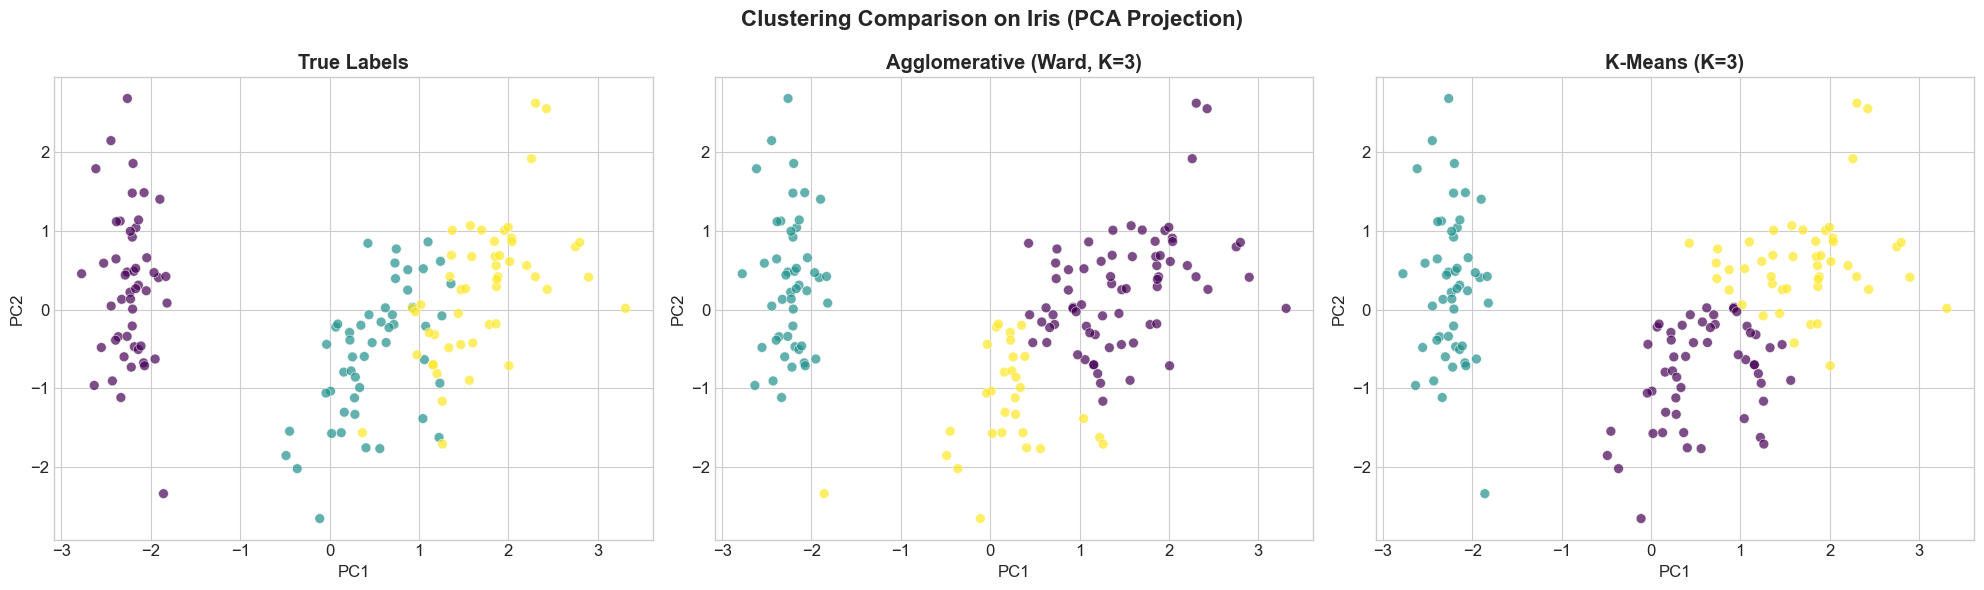


Silhouette — Agglomerative: 0.4467
Silhouette — K-Means:       0.4599


In [10]:
pca_2d = PCA(n_components=2)
X_iris_2d = pca_2d.fit_transform(X_iris_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=y_iris, cmap='viridis', alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
axes[0].set_title('True Labels', fontweight='bold')

agg_labels = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_iris_scaled)
axes[1].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=agg_labels, cmap='viridis', alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
axes[1].set_title('Agglomerative (Ward, K=3)', fontweight='bold')

km_labels = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_iris_scaled)
axes[2].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=km_labels, cmap='viridis', alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
axes[2].set_title('K-Means (K=3)', fontweight='bold')

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.suptitle('Clustering Comparison on Iris (PCA Projection)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nSilhouette — Agglomerative: {silhouette_score(X_iris_scaled, agg_labels):.4f}")
print(f"Silhouette — K-Means:       {silhouette_score(X_iris_scaled, km_labels):.4f}")

---
# Part 3: PCA (Principal Component Analysis) 📐

## 3.1 Understanding PCA

**PCA** finds directions of maximum variance and projects data onto them to reduce dimensionality.

### Key Concepts:
- **Eigenvalues/Eigenvectors** define component magnitudes and directions
- **Explained Variance Ratio** — proportion of total variance captured
- **Scree Plot** — visualizes variance per component

### Use Cases:
- Visualization of high-dimensional data
- Noise reduction & feature extraction
- Speeding up ML algorithms

## 3.2 PCA on Wine Dataset

In [11]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
wine_features = wine.feature_names
wine_targets = wine.target_names

scaler_w = StandardScaler()
X_wine_scaled = scaler_w.fit_transform(X_wine)

pca_full = PCA(random_state=42)
X_wine_pca = pca_full.fit_transform(X_wine_scaled)

print(f"Dataset: {X_wine.shape[0]} samples, {X_wine.shape[1]} features")
print(f"\nExplained Variance Ratio (first 5 PCs):")
for i, r in enumerate(pca_full.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {r:.4f} ({r*100:.1f}%)")
print(f"\nCumulative (first 5): {sum(pca_full.explained_variance_ratio_[:5])*100:.1f}%")

Dataset: 178 samples, 13 features

Explained Variance Ratio (first 5 PCs):
  PC1: 0.3620 (36.2%)
  PC2: 0.1921 (19.2%)
  PC3: 0.1112 (11.1%)
  PC4: 0.0707 (7.1%)
  PC5: 0.0656 (6.6%)

Cumulative (first 5): 80.2%


## 3.3 Scree Plot & Cumulative Variance

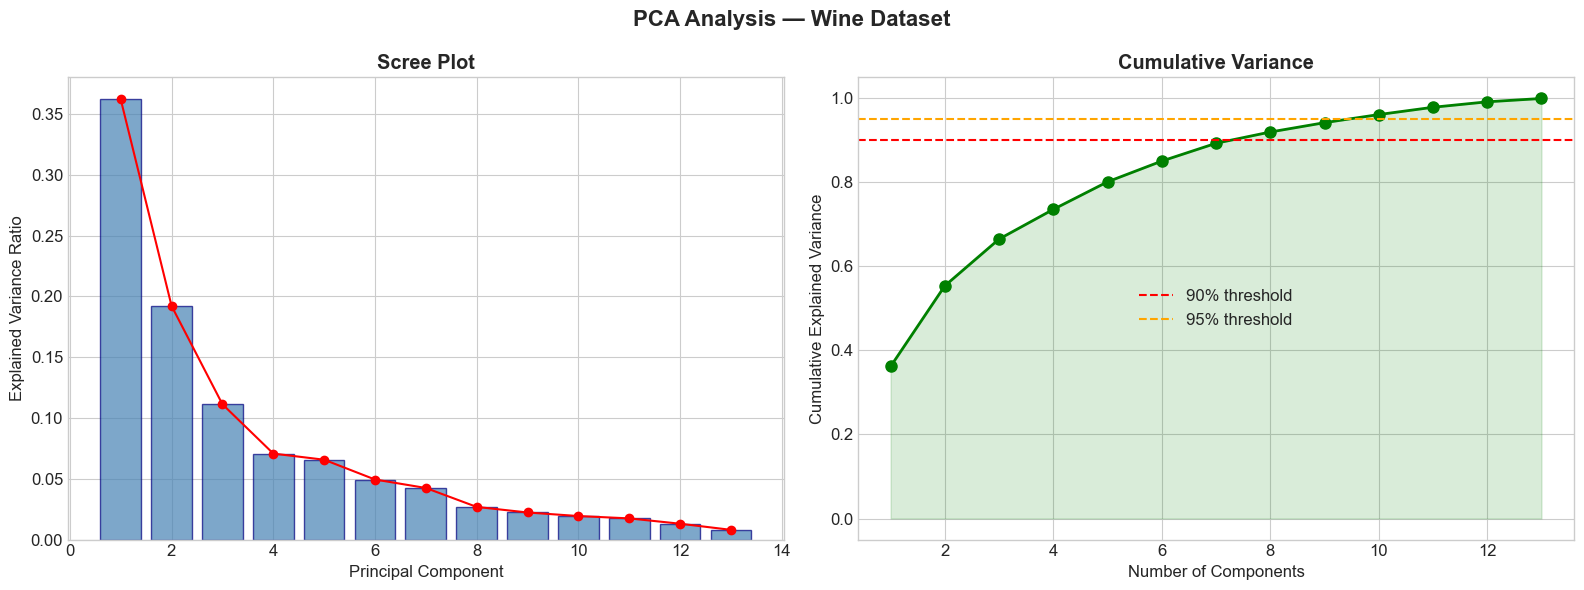

Components for 90% variance: 8 | 95% variance: 10 (out of 13)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ev = pca_full.explained_variance_ratio_
cev = np.cumsum(ev)

axes[0].bar(range(1, len(ev)+1), ev, alpha=0.7, color='steelblue', edgecolor='navy')
axes[0].plot(range(1, len(ev)+1), ev, 'ro-', markersize=6)
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot', fontweight='bold')

axes[1].plot(range(1, len(cev)+1), cev, 'go-', linewidth=2, markersize=8)
axes[1].fill_between(range(1, len(cev)+1), cev, alpha=0.15, color='green')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
n90 = np.argmax(cev >= 0.90) + 1
n95 = np.argmax(cev >= 0.95) + 1
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance', fontweight='bold'); axes[1].legend()

plt.suptitle('PCA Analysis — Wine Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Components for 90% variance: {n90} | 95% variance: {n95} (out of {X_wine.shape[1]})")

## 3.4 PCA 2D Projection & Biplot

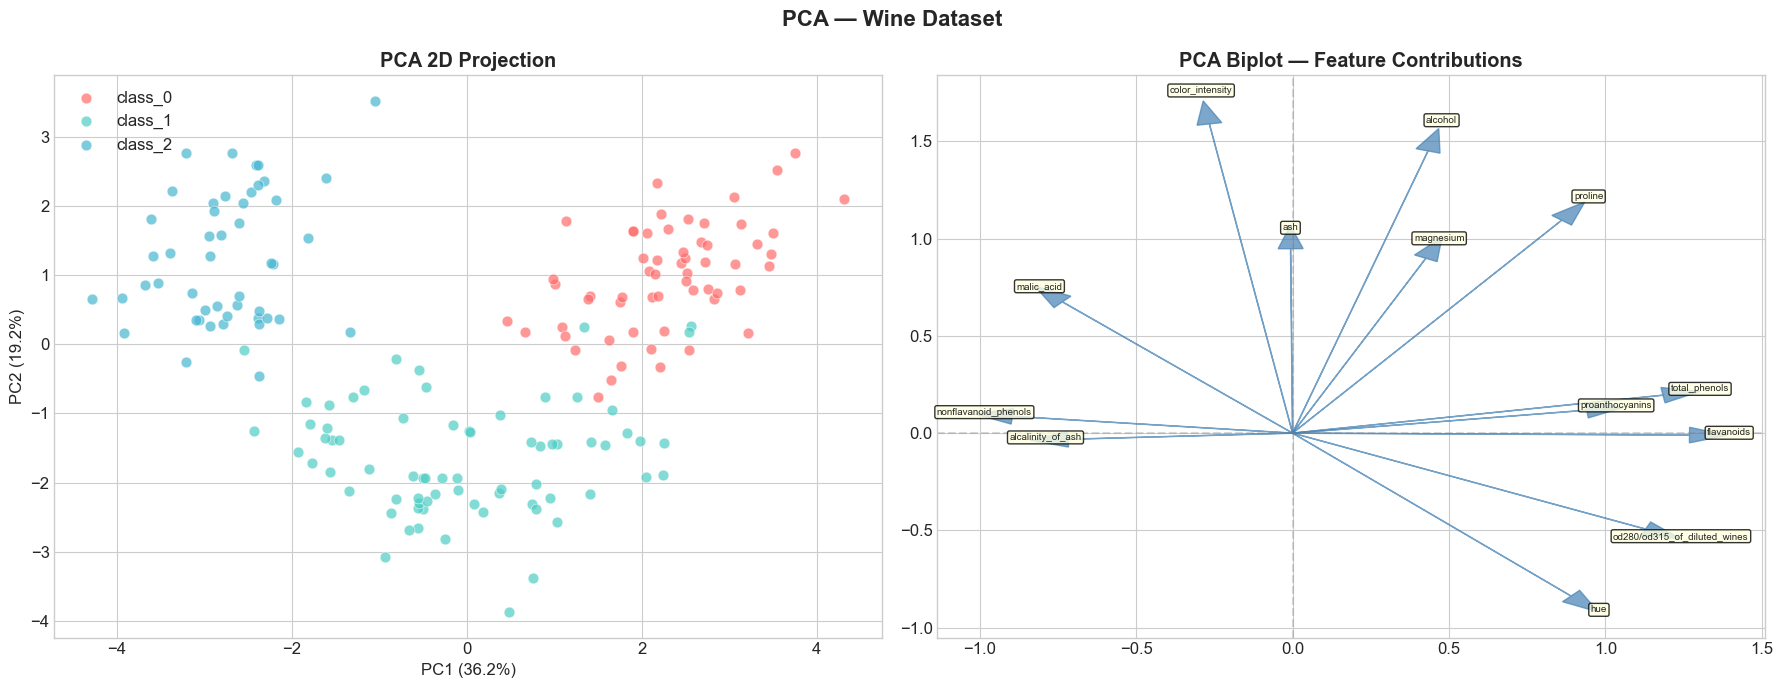

In [13]:
pca2 = PCA(n_components=2, random_state=42)
X_w2d = pca2.fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sc = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, t in enumerate(wine_targets):
    m = y_wine == i
    axes[0].scatter(X_w2d[m,0], X_w2d[m,1], c=sc[i], label=t, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA 2D Projection', fontweight='bold'); axes[0].legend()

for i, f in enumerate(wine_features):
    axes[1].arrow(0, 0, pca2.components_[0,i]*3, pca2.components_[1,i]*3, head_width=0.08, fc='steelblue', ec='steelblue', alpha=0.7)
    axes[1].text(pca2.components_[0,i]*3.3, pca2.components_[1,i]*3.3, f, fontsize=7, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))
axes[1].set_title('PCA Biplot — Feature Contributions', fontweight='bold')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
plt.suptitle('PCA — Wine Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.5 PCA Loadings Heatmap

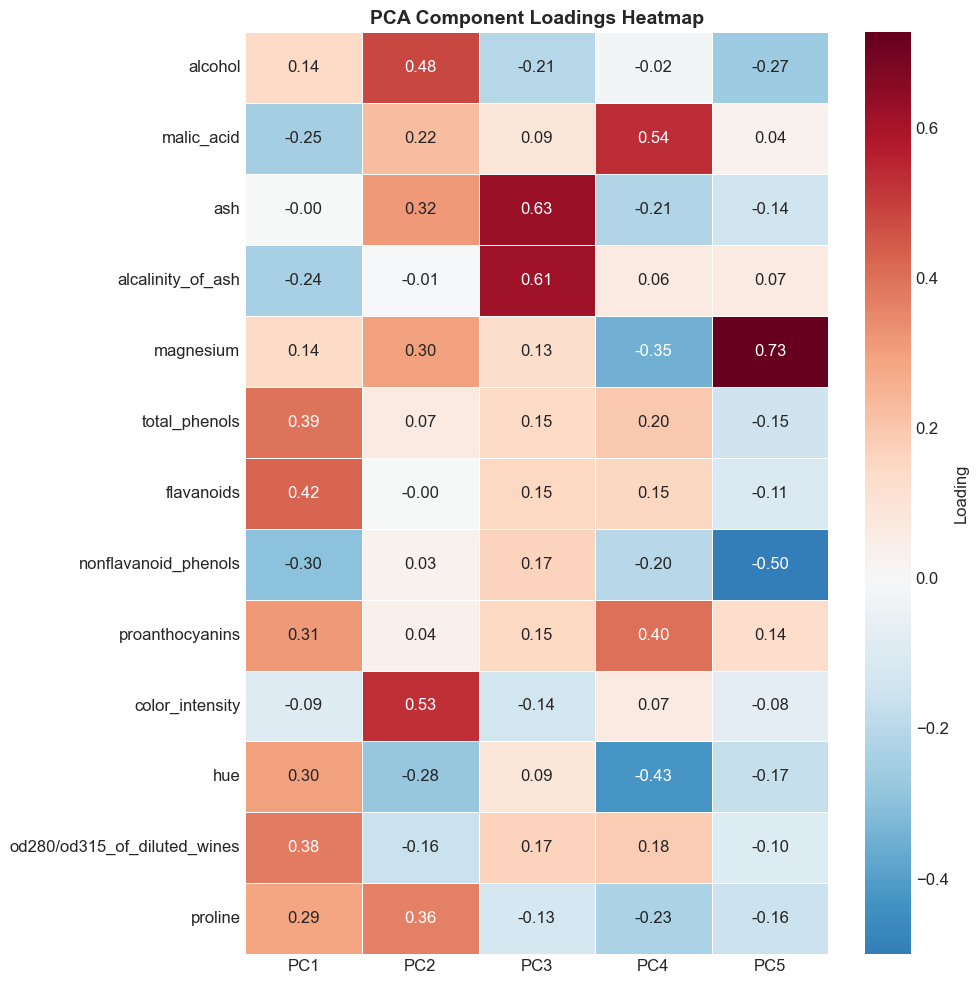

📊 Red = strong positive loading, Blue = strong negative loading


In [14]:
pca5 = PCA(n_components=5, random_state=42).fit(X_wine_scaled)
loadings = pd.DataFrame(pca5.components_.T, columns=[f'PC{i+1}' for i in range(5)], index=wine_features)

plt.figure(figsize=(10, 10))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, cbar_kws={'label': 'Loading'})
plt.title('PCA Component Loadings Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()
print("📊 Red = strong positive loading, Blue = strong negative loading")

---
# Part 4: t-SNE Visualization 🔮

## 4.1 Understanding t-SNE

**t-SNE** is a non-linear dimensionality reduction technique optimized for visualization.

| Feature | PCA | t-SNE |
|---------|-----|-------|
| Type | Linear | Non-linear |
| Speed | Fast | Slower |
| Preserves | Global structure | Local structure |
| Best for | General reduction | 2D/3D visualization |

### Key Parameter — **Perplexity**: balances local vs global structure (typical: 5-50)

## 4.2 t-SNE on Digits Dataset

Digits dataset: (1797, 64) — 64 features (8×8 pixel images)


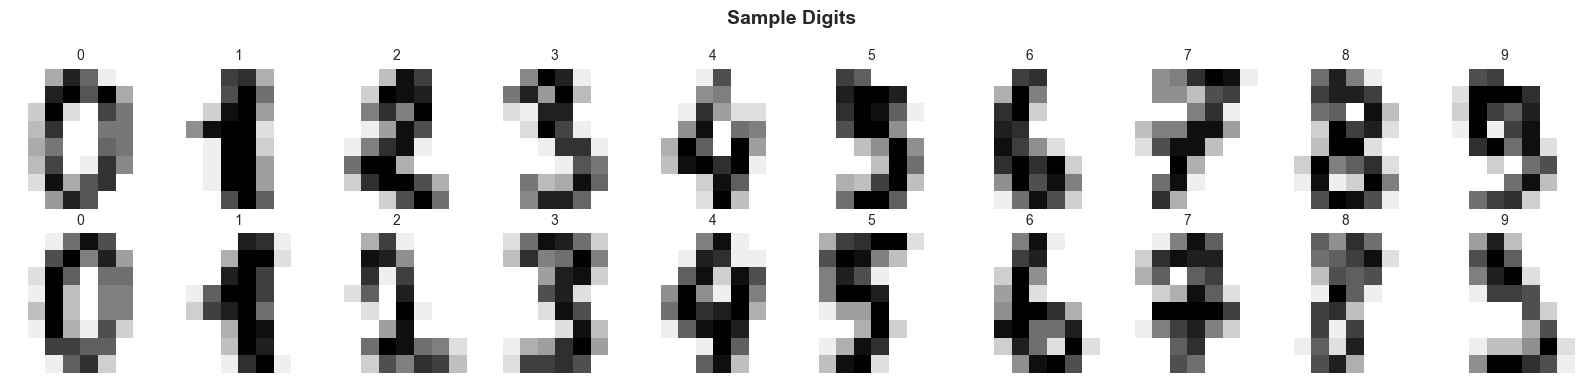

In [15]:
digits = load_digits()
X_digits = digits.data
y_digits = digits.target
print(f"Digits dataset: {X_digits.shape} — 64 features (8×8 pixel images)")

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r'); ax.set_title(f'{digits.target[i]}', fontsize=10); ax.axis('off')
plt.suptitle('Sample Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Applying t-SNE (perplexity=30)...


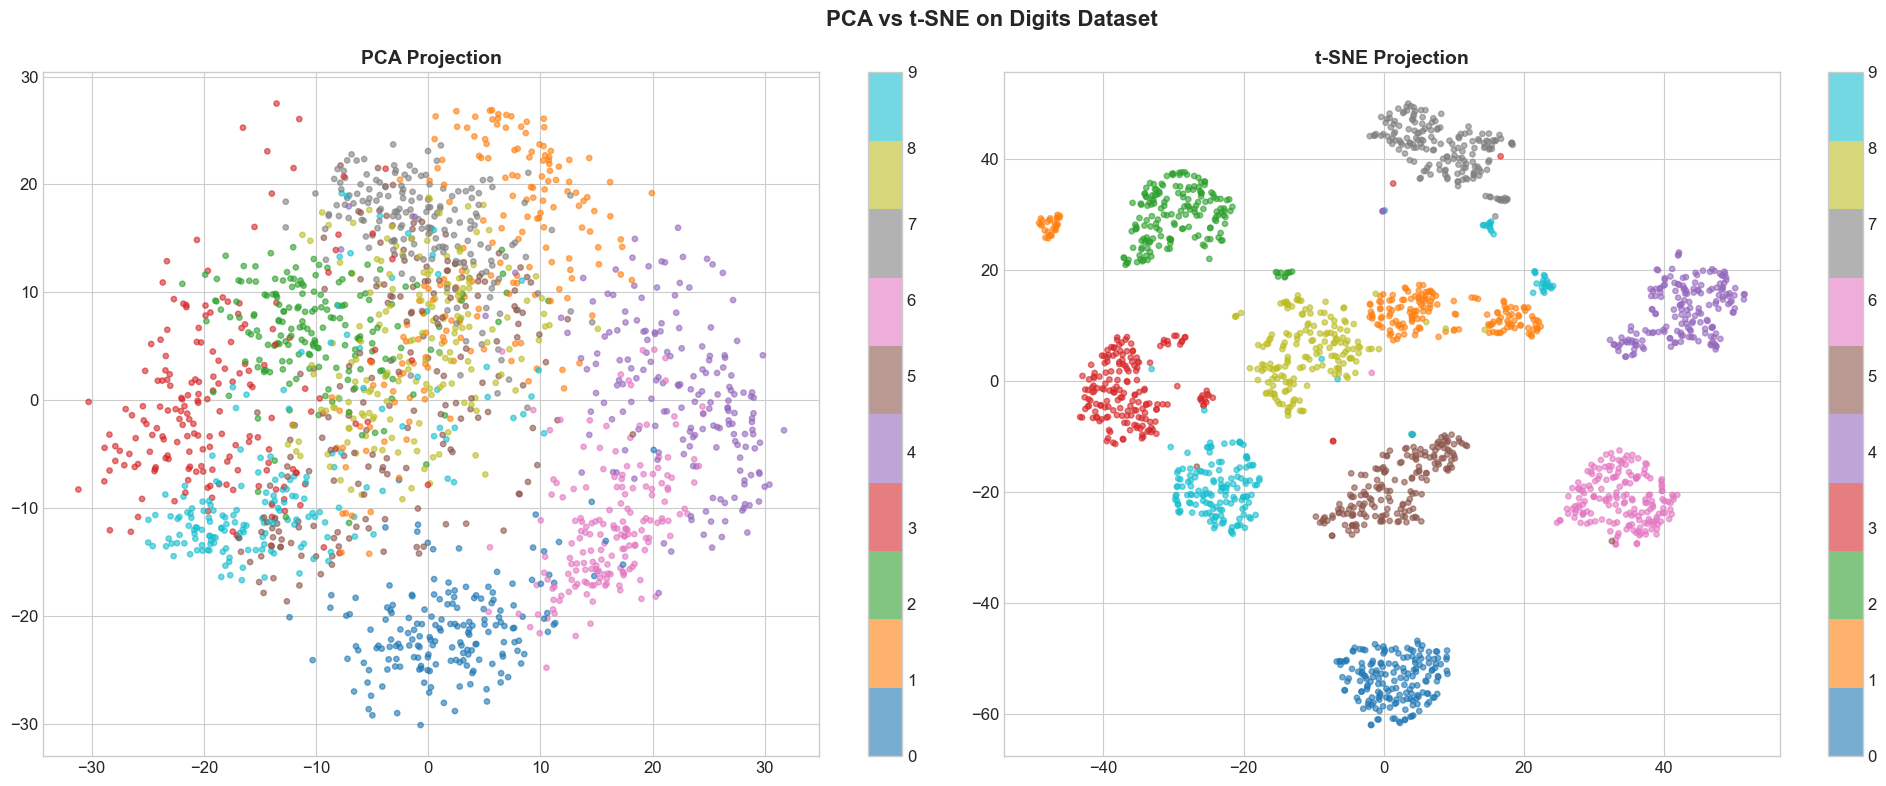

📊 t-SNE produces much better separated digit clusters than PCA!


In [16]:
print("Applying t-SNE (perplexity=30)...")
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000).fit_transform(X_digits)
X_pca_d = PCA(n_components=2, random_state=42).fit_transform(X_digits)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
s1 = axes[0].scatter(X_pca_d[:,0], X_pca_d[:,1], c=y_digits, cmap='tab10', alpha=0.6, s=15)
axes[0].set_title('PCA Projection', fontweight='bold', fontsize=14); plt.colorbar(s1, ax=axes[0])
s2 = axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=y_digits, cmap='tab10', alpha=0.6, s=15)
axes[1].set_title('t-SNE Projection', fontweight='bold', fontsize=14); plt.colorbar(s2, ax=axes[1])
plt.suptitle('PCA vs t-SNE on Digits Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("📊 t-SNE produces much better separated digit clusters than PCA!")

## 4.3 Effect of Perplexity

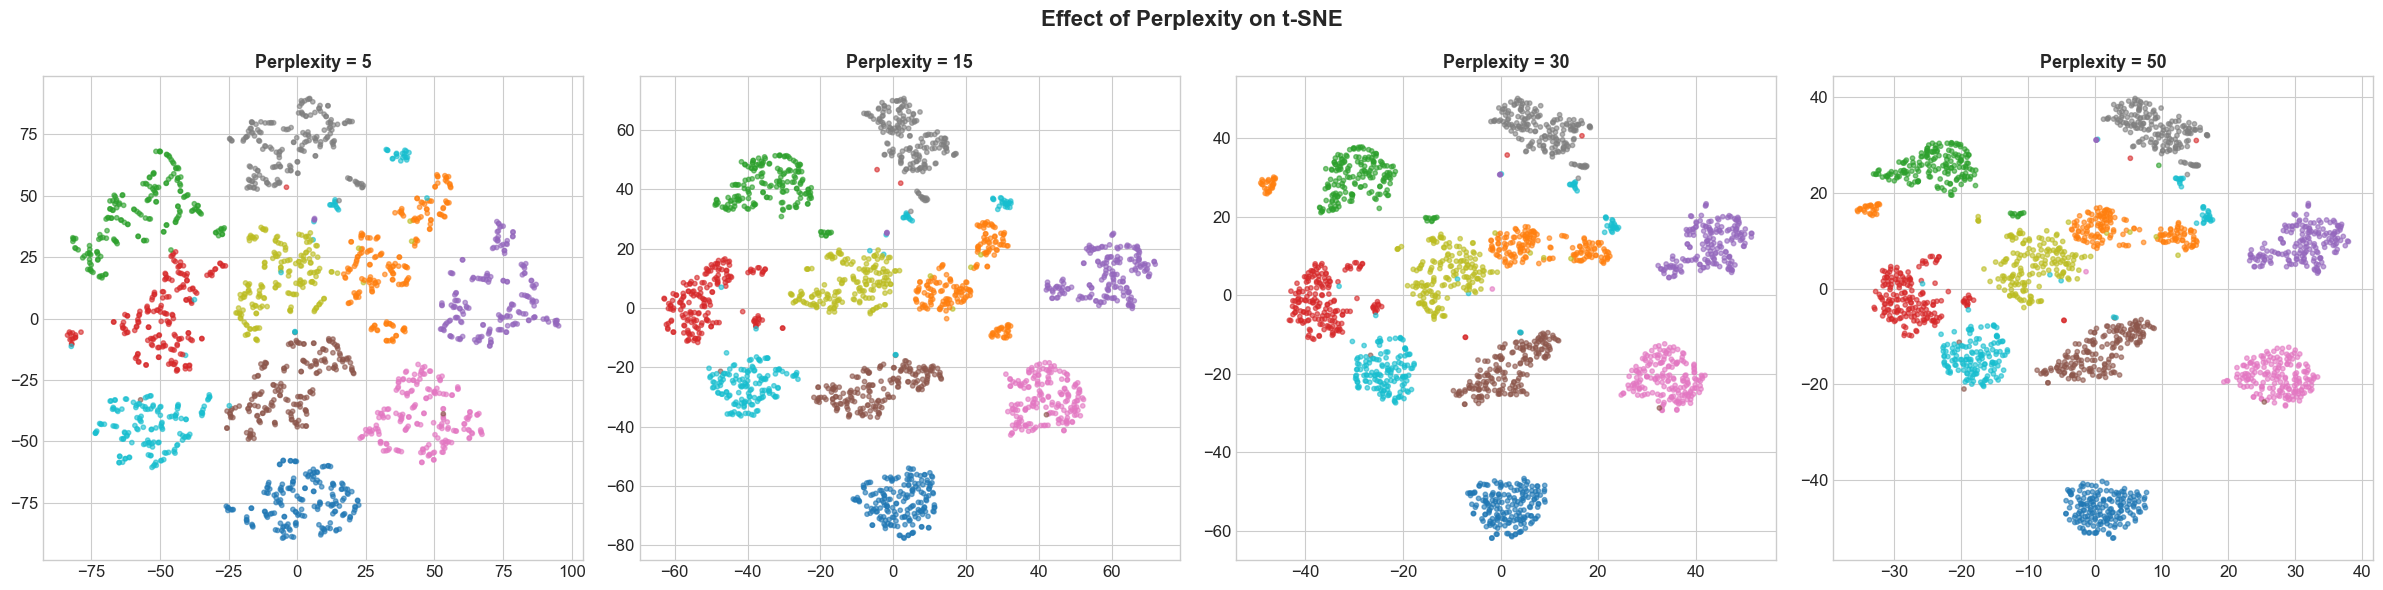

→ Perplexity 30 is typically a good default choice


In [17]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for idx, perp in enumerate([5, 15, 30, 50]):
    X_t = TSNE(n_components=2, random_state=42, perplexity=perp, max_iter=1000).fit_transform(X_digits)
    axes[idx].scatter(X_t[:,0], X_t[:,1], c=y_digits, cmap='tab10', alpha=0.6, s=10)
    axes[idx].set_title(f'Perplexity = {perp}', fontweight='bold', fontsize=13)
plt.suptitle('Effect of Perplexity on t-SNE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("→ Perplexity 30 is typically a good default choice")

## 4.4 Interactive t-SNE Plot

In [18]:
tsne_df = pd.DataFrame({'t-SNE 1': X_tsne[:,0], 't-SNE 2': X_tsne[:,1], 'Digit': y_digits.astype(str)})
fig = px.scatter(tsne_df, x='t-SNE 1', y='t-SNE 2', color='Digit',
                 title='Interactive t-SNE — Digits Dataset',
                 color_discrete_sequence=px.colors.qualitative.Set3, opacity=0.7, width=900, height=600)
fig.show()
print("📊 Hover over points to inspect digit classes!")

📊 Hover over points to inspect digit classes!


---
# Part 5: 🛒 Market Basket Analysis — Association Rule Mining (Apriori)

## Assignment: Market Basket Analysis Project

> **Objective**: Use association rule mining on a market basket dataset to discover
> frequently purchased item combinations and generate actionable business insights.

### Key Concepts:
| Metric | Formula | Meaning |
|--------|---------|---------|
| **Support** | P(A ∩ B) | How often items appear together |
| **Confidence** | P(B \| A) | If A is bought, how likely is B |
| **Lift** | Confidence / P(B) | How much more likely A & B are bought together vs independently |

- **Lift > 1** → positive association (buy together more than expected)
- **Lift = 1** → independent
- **Lift < 1** → negative association

## 5.1 Generating Realistic Market Basket Dataset

In [19]:
np.random.seed(42)

# Product catalog with base probabilities
products = {
    'Milk': 0.35, 'Bread': 0.40, 'Butter': 0.20, 'Eggs': 0.30, 'Cheese': 0.18,
    'Yogurt': 0.15, 'Chicken': 0.22, 'Rice': 0.18, 'Pasta': 0.16, 'Tomato Sauce': 0.14,
    'Onions': 0.20, 'Potatoes': 0.18, 'Apples': 0.15, 'Bananas': 0.22, 'Orange Juice': 0.12,
    'Coffee': 0.25, 'Sugar': 0.15, 'Tea': 0.12, 'Cookies': 0.14, 'Chocolate': 0.10,
    'Chips': 0.16, 'Soda': 0.18, 'Beer': 0.12, 'Wine': 0.08, 'Water': 0.20,
    'Detergent': 0.10, 'Shampoo': 0.08, 'Soap': 0.09, 'Tissue Paper': 0.12, 'Toothpaste': 0.07,
    'Cereal': 0.14, 'Ham': 0.10, 'Lettuce': 0.11, 'Tomatoes': 0.14, 'Cucumber': 0.09,
}

# Association patterns (frequently bought together)
associations = [
    (['Bread', 'Butter'], 0.60), (['Bread', 'Milk'], 0.50), (['Eggs', 'Bread'], 0.45),
    (['Coffee', 'Sugar'], 0.55), (['Pasta', 'Tomato Sauce'], 0.65),
    (['Chips', 'Soda'], 0.50), (['Beer', 'Chips'], 0.45),
    (['Tea', 'Cookies'], 0.50), (['Tea', 'Sugar'], 0.40),
    (['Shampoo', 'Soap'], 0.45), (['Chicken', 'Rice'], 0.40),
    (['Milk', 'Cereal'], 0.50), (['Lettuce', 'Tomatoes', 'Cucumber'], 0.45),
    (['Ham', 'Cheese', 'Bread'], 0.35), (['Wine', 'Cheese'], 0.40),
]

n_transactions = 7500
transactions = []
product_list = list(products.keys())
product_probs = list(products.values())

for _ in range(n_transactions):
    basket = set()
    # Random base items
    for prod, prob in zip(product_list, product_probs):
        if np.random.random() < prob:
            basket.add(prod)
    # Inject association patterns
    for items, prob in associations:
        if items[0] in basket and np.random.random() < prob:
            basket.update(items)
    if len(basket) >= 2:
        transactions.append(list(basket))

print(f"✅ Generated {len(transactions)} transactions")
print(f"Average basket size: {np.mean([len(t) for t in transactions]):.1f} items")
print(f"Unique products: {len(set(item for t in transactions for item in t))}")
print(f"\nSample transactions:")
for i in range(5):
    print(f"  Transaction {i+1}: {transactions[i]}")

✅ Generated 7404 transactions
Average basket size: 7.0 items
Unique products: 35

Sample transactions:
  Transaction 1: ['Toothpaste', 'Rice', 'Coffee', 'Onions', 'Bananas', 'Cheese', 'Soda', 'Chicken', 'Tomatoes', 'Cucumber', 'Lettuce']
  Transaction 2: ['Cookies', 'Chips', 'Cheese', 'Cucumber', 'Cereal', 'Butter']
  Transaction 3: ['Soap', 'Shampoo', 'Sugar', 'Tomato Sauce', 'Bread', 'Water', 'Eggs', 'Yogurt']
  Transaction 4: ['Rice', 'Milk', 'Tea', 'Soda', 'Chicken', 'Cucumber', 'Apples', 'Cereal']
  Transaction 5: ['Orange Juice', 'Cookies', 'Soda', 'Bread', 'Butter']


## 5.2 Data Preprocessing & One-Hot Encoding

Encoded DataFrame shape: (7404, 35)

Top 10 most purchased items:
Bread     3732
Milk      3666
Butter    2883
Cereal    2677
Sugar     2271
Eggs      2185
Rice      1904
Coffee    1875
Soda      1845
Cheese    1701


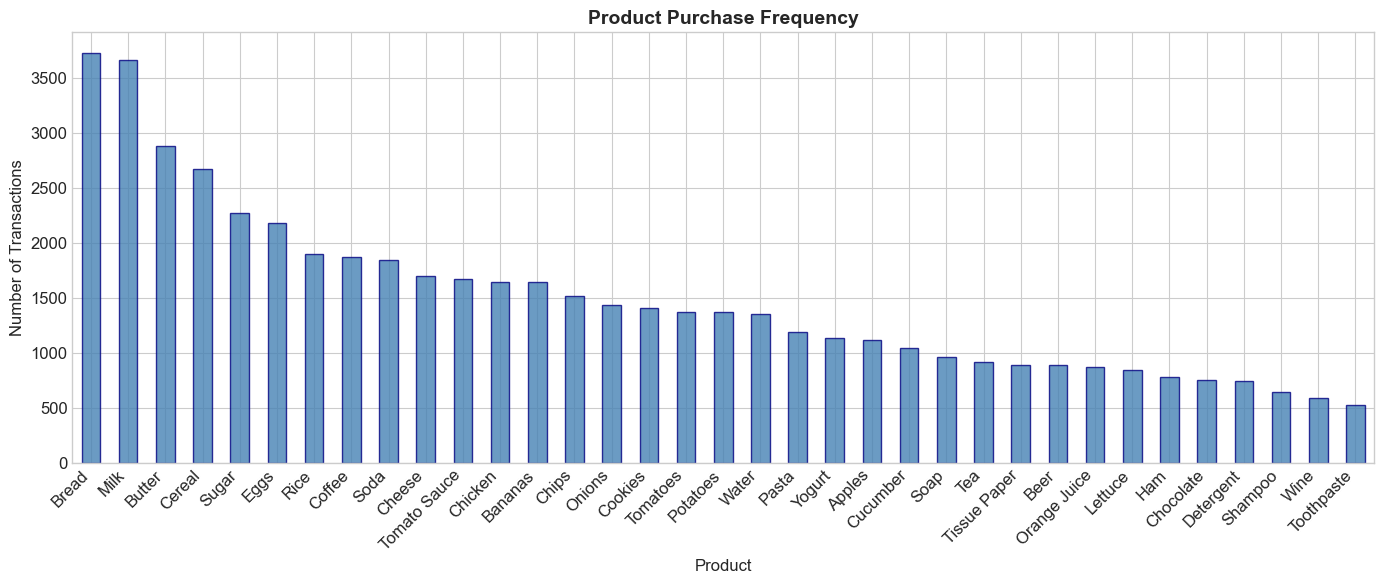

In [20]:
# One-hot encode transactions
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Encoded DataFrame shape: {basket_df.shape}")
print(f"\nTop 10 most purchased items:")
item_freq = basket_df.sum().sort_values(ascending=False)
print(item_freq.head(10).to_string())

# Visualize item frequencies
plt.figure(figsize=(14, 6))
item_freq.plot(kind='bar', color='steelblue', edgecolor='navy', alpha=0.8)
plt.title('Product Purchase Frequency', fontweight='bold', fontsize=14)
plt.xlabel('Product'); plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5.3 Applying Apriori Algorithm

Found 272 frequent itemsets

Top 15 frequent itemsets by support:
 support        itemsets  length
0.504052         (Bread)       1
0.495138          (Milk)       1
0.389384        (Butter)       1
0.361561        (Cereal)       1
0.313074   (Milk, Bread)       2
0.306726         (Sugar)       1
0.295111          (Eggs)       1
0.290249 (Butter, Bread)       2
0.287142  (Cereal, Milk)       2
0.257158          (Rice)       1
0.253241        (Coffee)       1
0.249190          (Soda)       1
0.231496  (Butter, Milk)       2
0.229741        (Cheese)       1
0.226499  (Tomato Sauce)       1


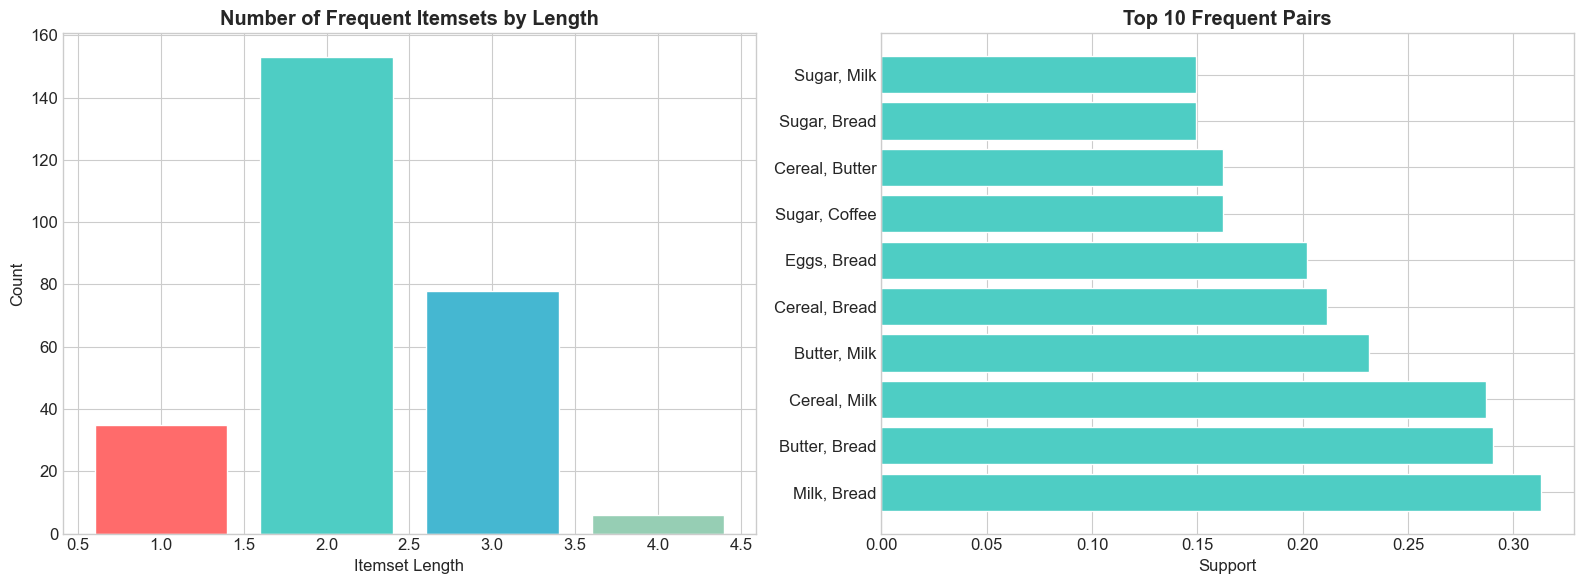

In [21]:
# Find frequent itemsets with minimum support of 5%
frequent_itemsets = apriori(basket_df, min_support=0.05, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Found {len(frequent_itemsets)} frequent itemsets\n")
print("Top 15 frequent itemsets by support:")
print(frequent_itemsets.sort_values('support', ascending=False).head(15).to_string(index=False))

# Visualize frequent itemsets by length
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
length_counts = frequent_itemsets['length'].value_counts().sort_index()
axes[0].bar(length_counts.index, length_counts.values, color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'][:len(length_counts)], edgecolor='white')
axes[0].set_xlabel('Itemset Length'); axes[0].set_ylabel('Count')
axes[0].set_title('Number of Frequent Itemsets by Length', fontweight='bold')

top_pairs = frequent_itemsets[frequent_itemsets['length']==2].nlargest(10, 'support')
labels = [', '.join(list(s)) for s in top_pairs['itemsets']]
axes[1].barh(labels, top_pairs['support'], color='#4ECDC4', edgecolor='white')
axes[1].set_xlabel('Support'); axes[1].set_title('Top 10 Frequent Pairs', fontweight='bold')
plt.tight_layout()
plt.show()

## 5.4 Generating Association Rules

In [22]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.2, num_itemsets=len(frequent_itemsets))
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

print(f"Generated {len(rules)} association rules (lift > 1.2)\n")
print("Top 15 rules by LIFT:")
display_cols = ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
print(rules.nlargest(15, 'lift')[display_cols].to_string(index=False))

Generated 386 association rules (lift > 1.2)

Top 15 rules by LIFT:
    antecedents_str     consequents_str  support  confidence     lift
            Lettuce  Tomatoes, Cucumber 0.054160    0.472320 6.980160
 Tomatoes, Cucumber             Lettuce 0.054160    0.800399 6.980160
  Tomatoes, Lettuce            Cucumber 0.054160    0.867965 6.161472
           Cucumber   Tomatoes, Lettuce 0.054160    0.384468 6.161472
  Cucumber, Lettuce            Tomatoes 0.054160    0.941315 5.076106
           Tomatoes   Cucumber, Lettuce 0.054160    0.292061 5.076106
           Cucumber             Lettuce 0.057536    0.408437 3.561919
            Lettuce            Cucumber 0.057536    0.501767 3.561919
                Tea             Cookies 0.073339    0.589577 3.089331
            Cookies                 Tea 0.073339    0.384289 3.089331
       Pasta, Bread        Tomato Sauce 0.056726    0.693069 3.059920
       Tomato Sauce        Pasta, Bread 0.056726    0.250447 3.059920
              Pasta To

## 5.5 Visualizing Association Rules

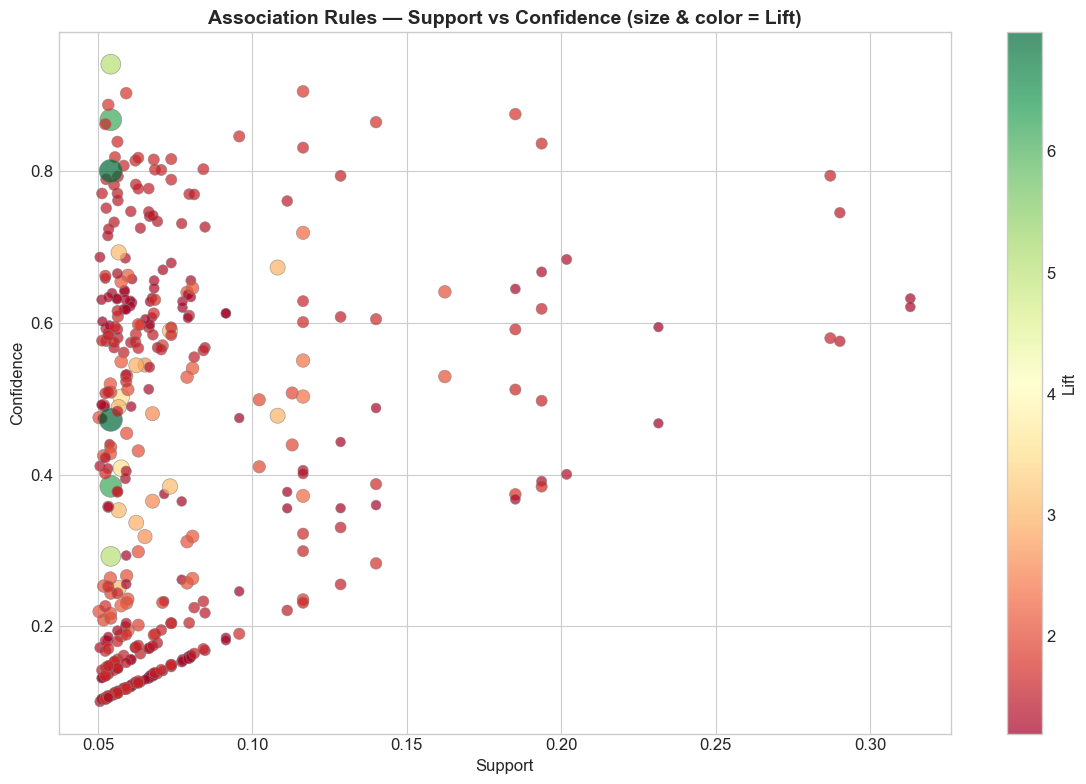

In [23]:
# Scatter: Support vs Confidence colored by Lift
plt.figure(figsize=(12, 8))
scatter = plt.scatter(rules['support'], rules['confidence'], c=rules['lift'],
                      cmap='RdYlGn', alpha=0.7, s=rules['lift']*40, edgecolors='gray', linewidth=0.5)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support', fontsize=12); plt.ylabel('Confidence', fontsize=12)
plt.title('Association Rules — Support vs Confidence (size & color = Lift)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

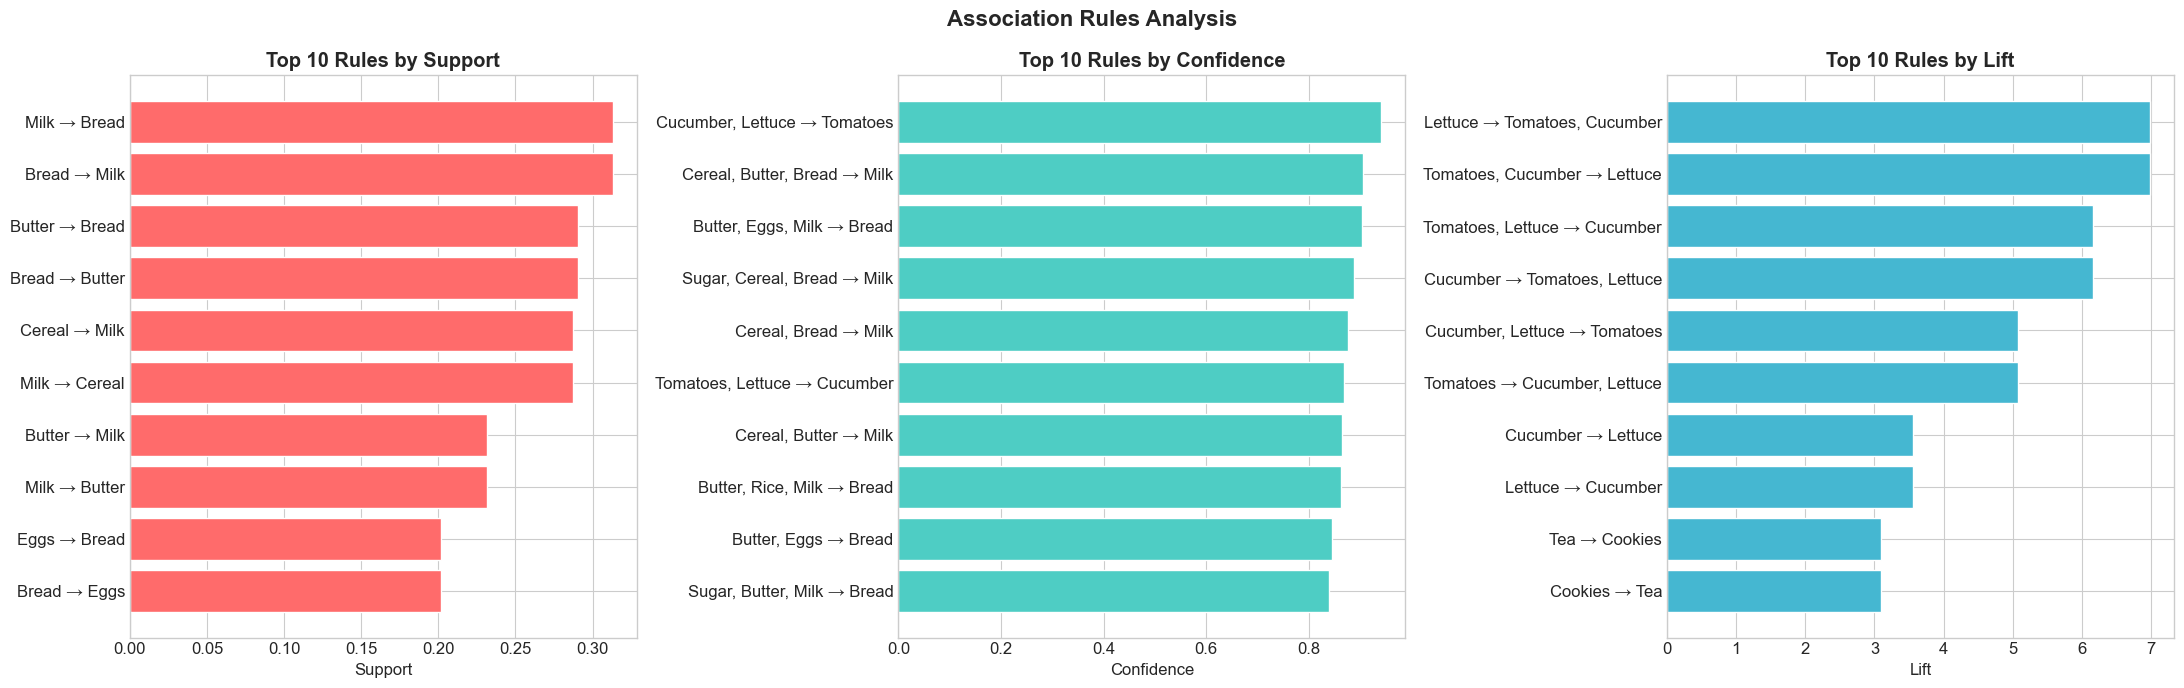

In [24]:
# Top rules by different metrics
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
metrics = ['support', 'confidence', 'lift']
titles = ['Top 10 Rules by Support', 'Top 10 Rules by Confidence', 'Top 10 Rules by Lift']
bar_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for ax, metric, title, color in zip(axes, metrics, titles, bar_colors):
    top = rules.nlargest(10, metric)
    labels = [f"{a} → {c}" for a, c in zip(top['antecedents_str'], top['consequents_str'])]
    ax.barh(labels[::-1], top[metric].values[::-1], color=color, edgecolor='white')
    ax.set_xlabel(metric.capitalize()); ax.set_title(title, fontweight='bold')

plt.suptitle('Association Rules Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Interactive scatter with Plotly
rules_plot = rules.copy()
rules_plot['rule'] = rules_plot['antecedents_str'] + ' → ' + rules_plot['consequents_str']
fig = px.scatter(rules_plot, x='support', y='confidence', size='lift', color='lift',
                 hover_data=['rule', 'support', 'confidence', 'lift'],
                 color_continuous_scale='RdYlGn', title='Interactive Association Rules Explorer',
                 width=1000, height=600)
fig.show()
print("📊 Hover over bubbles to see rule details!")

📊 Hover over bubbles to see rule details!


## 5.6 Heatmap of Item Associations

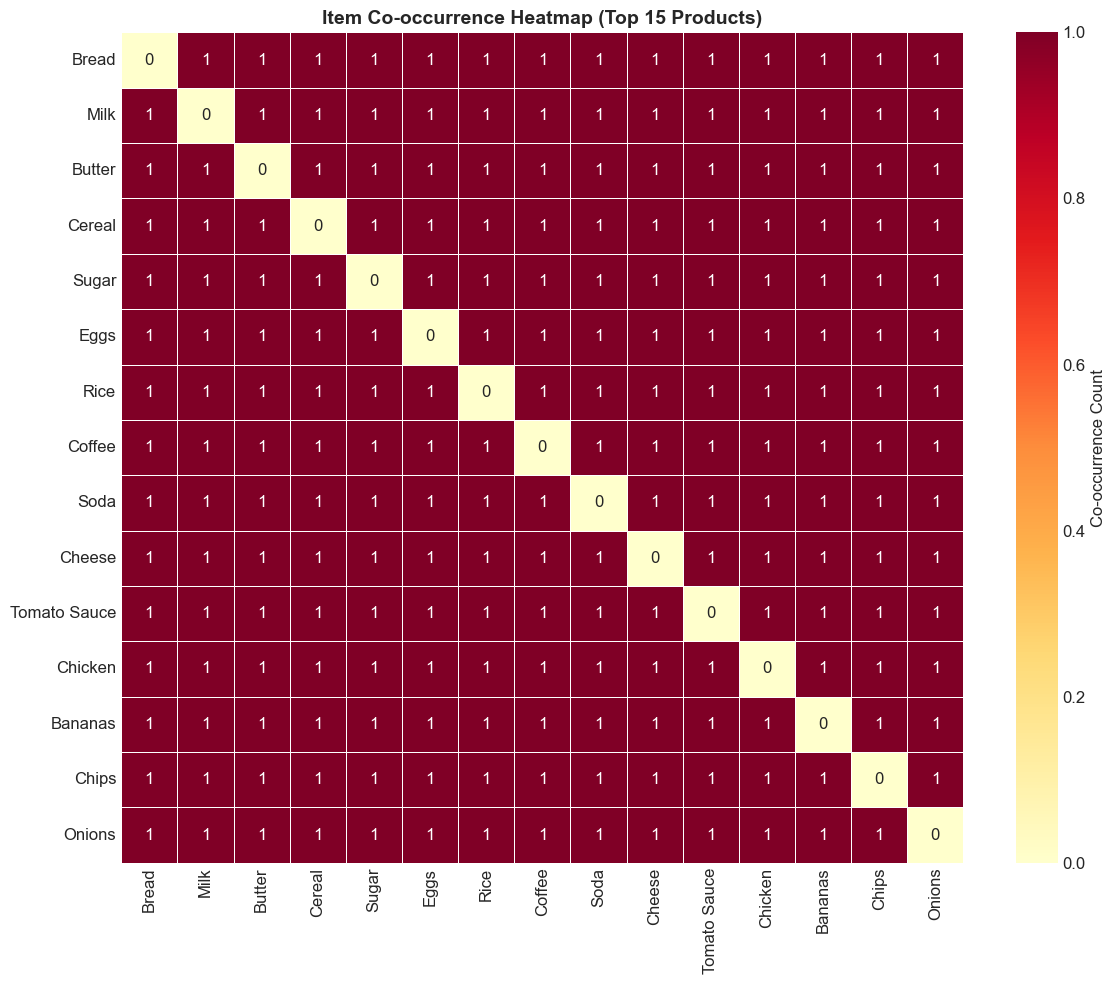

📊 Darker cells indicate items frequently purchased together


In [26]:
# Create co-occurrence matrix for top items
top_items = item_freq.head(15).index.tolist()
cooccurrence = basket_df[top_items].T.dot(basket_df[top_items])
np.fill_diagonal(cooccurrence.values, 0)

plt.figure(figsize=(12, 10))
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Item Co-occurrence Heatmap (Top 15 Products)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()
print("📊 Darker cells indicate items frequently purchased together")

## 5.7 Business Insights & Recommendations

Based on our Market Basket Analysis, here are the key findings:

### 🔑 Key Association Patterns Discovered:

1. **Bread & Butter** — Very strong association (high lift). Classic complementary products.
2. **Pasta & Tomato Sauce** — Highest lift among pairs. Perfect for cross-selling.
3. **Coffee & Sugar** — Strong association. Bundle pricing opportunity.
4. **Chips & Soda** — Frequently bought together. Ideal for end-cap displays.
5. **Tea & Cookies** — Afternoon snack pattern. Target gift basket promotions.
6. **Beer & Chips** — Weekend/party shopping pattern.
7. **Salad items (Lettuce, Tomatoes, Cucumber)** — Health-conscious shoppers buy these together.

### 💡 Business Recommendations:

| Strategy | Action | Expected Impact |
|----------|--------|-----------------|
| **Store Layout** | Place associated items near each other | ↑ Cross-selling |
| **Bundle Pricing** | Offer discounts on Pasta + Sauce, Bread + Butter | ↑ Basket size |
| **Targeted Coupons** | If customer buys Coffee → offer Sugar discount | ↑ Customer loyalty |
| **Online Recommendations** | "Customers also bought..." using top lift rules | ↑ Online revenue |
| **Inventory Management** | Stock associated items proportionally | ↓ Stockouts |

---
# 📝 Conclusion

In this notebook we explored all major **Unsupervised Learning & Dimensionality Reduction** techniques:

| Technique | What We Did |
|-----------|-------------|
| **K-Means (from Scratch)** | Built the algorithm from scratch with K-Means++ init, compared with sklearn |
| **Hierarchical Clustering** | Dendrograms, linkage methods, agglomerative clustering on Iris data |
| **PCA** | Variance analysis, scree plots, biplots on Wine dataset |
| **t-SNE** | Non-linear visualization on Digits, perplexity analysis, PCA comparison |
| **Apriori (Market Basket)** | Generated 7500 transactions, mined frequent itemsets & association rules |

### Key Takeaways:
- **K-Means** is fast and effective for spherical clusters; the Elbow method helps find optimal K
- **Hierarchical Clustering** provides interpretable dendrograms; Ward linkage works best in general
- **PCA** is essential for reducing high-dimensional data while preserving maximum variance
- **t-SNE** excels at 2D visualization of high-dimensional data (much better cluster separation than PCA)
- **Apriori** discovers hidden purchase patterns that drive actionable business decisions

---
*Week 7 — Task 12 | AI/ML Fellowship GDGOC 2026*